In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r"C:\Users\AS\Downloads\archive(5)\credit_risk_dataset.csv")

print(df.columns)
print("\n==================== SHAPE ====================")
print(df.shape)

print("\n==================== HEAD ====================")
print(df.head())

print("\n==================== INFO ====================")
print(df.info())

print("\n==================== DUPLICATES ====================")
print(df.duplicated().sum())

print("\n==================== MISSING VALUES (COUNT) ====================")
print(df.isnull().sum().sort_values(ascending=False))

print("\n==================== MISSING VALUES (%) ====================")
print((df.isnull().mean() * 100).sort_values(ascending=False))

print("\n==================== DESCRIBE NUMERIC ====================")
print(df.describe())



Index(['customer_id', 'age', 'gender', 'employment_status', 'annual_income',
       'account_age_months', 'avg_monthly_balance', 'num_deposits_per_month',
       'avg_deposit_amount', 'debit_card_usage_frequency',
       'debit_card_spending', 'mobile_banking_logins',
       'online_transfer_frequency', 'atm_withdrawal_frequency', 'credit_score',
       'num_open_loans', 'total_outstanding_debt', 'late_payment_count',
       'loan_default_history', 'fraud_flag', 'loan_application_amount',
       'credit_risk'],
      dtype='object')

==================== SHAPE ====================
(5000, 22)

==================== HEAD ====================
  customer_id  age  gender employment_status  annual_income  \
0  CUST_00000   58    Male        Unemployed   58137.751192   
1  CUST_00001   48    Male     Self-Employed   26174.922827   
2  CUST_00002   34   Other        Unemployed   75566.837265   
3  CUST_00003   62    Male     Self-Employed   35197.961516   
4  CUST_00004   27  Female     Self-Em

In [9]:
print("\n==================== DATA TYPES ====================")


print(df.dtypes)

# Try detecting target column automatically
possible_targets = ["loan_status", "default", "target", "y"]
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col:
    print(f"\n==================== TARGET: {target_col} ====================")
    print(df[target_col].value_counts())

    df[target_col].value_counts().plot(kind='bar')
    plt.title("Target Distribution")
    plt.show()
else:
    print("\n⚠️ No target column found (check manually)")

print("\n==================== NUM / CAT COLUMNS ====================")
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

print("\n✅ EDA DONE")


==================== DATA TYPES ====================
customer_id                    object
age                             int64
gender                         object
employment_status              object
annual_income                 float64
account_age_months              int64
avg_monthly_balance           float64
num_deposits_per_month          int64
avg_deposit_amount            float64
debit_card_usage_frequency      int64
debit_card_spending           float64
mobile_banking_logins           int64
online_transfer_frequency       int64
atm_withdrawal_frequency        int64
credit_score                    int64
num_open_loans                  int64
total_outstanding_debt        float64
late_payment_count              int64
loan_default_history            int64
fraud_flag                      int64
loan_application_amount       float64
credit_risk                     int64
dtype: object

⚠️ No target column found (check manually)

==================== NUM / CAT COLUMNS ============

Shape: (5000, 22)


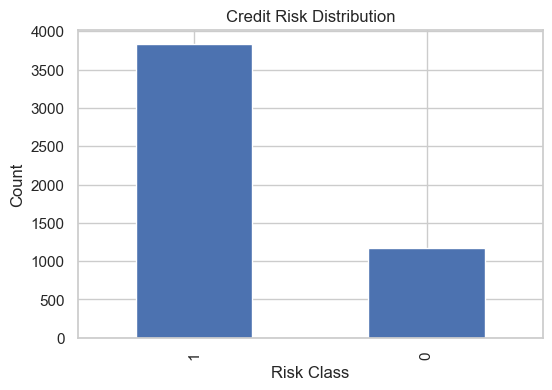

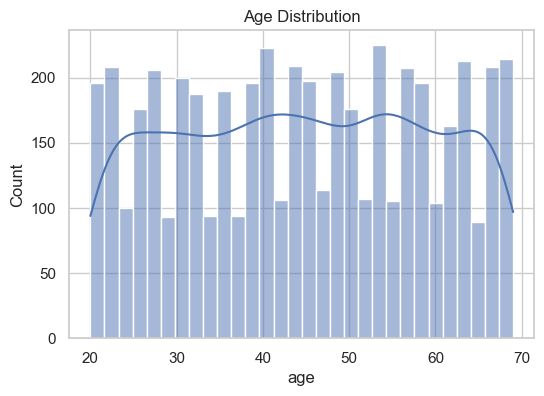

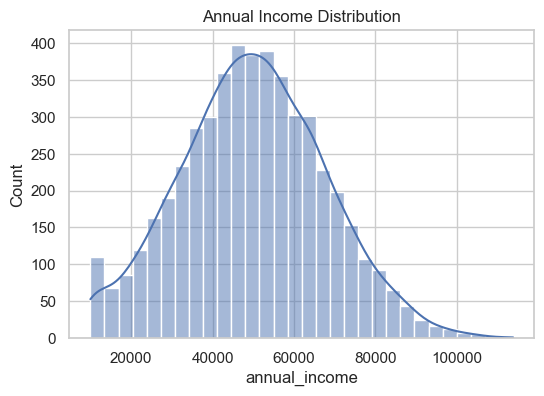

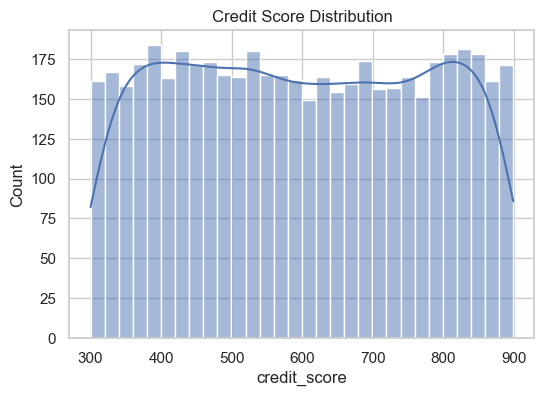

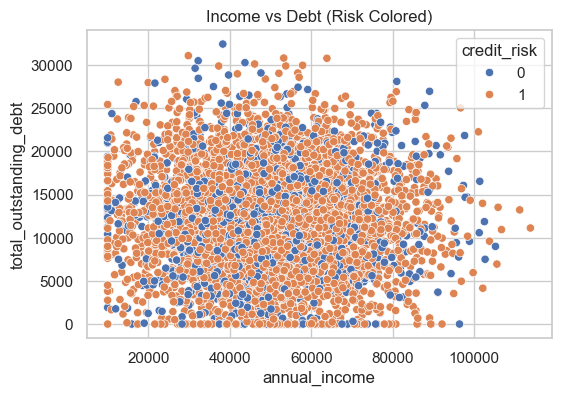

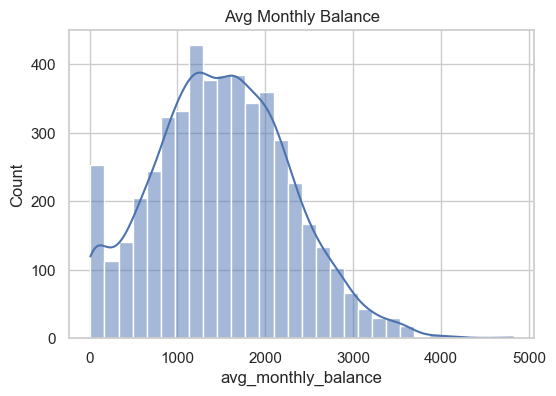

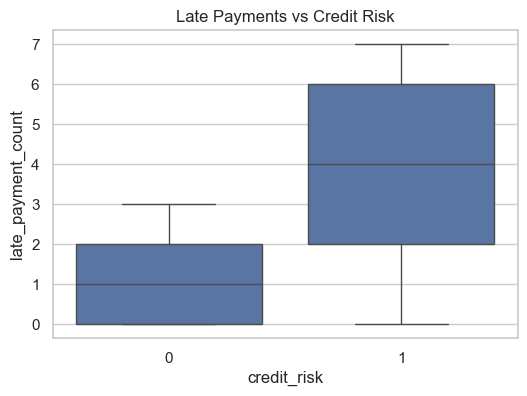

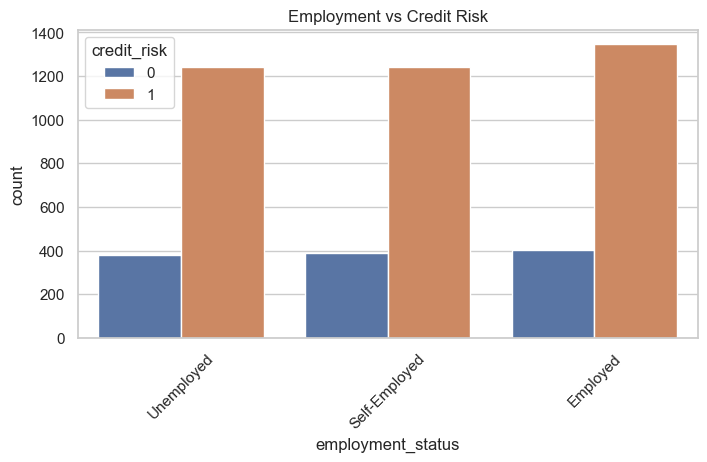

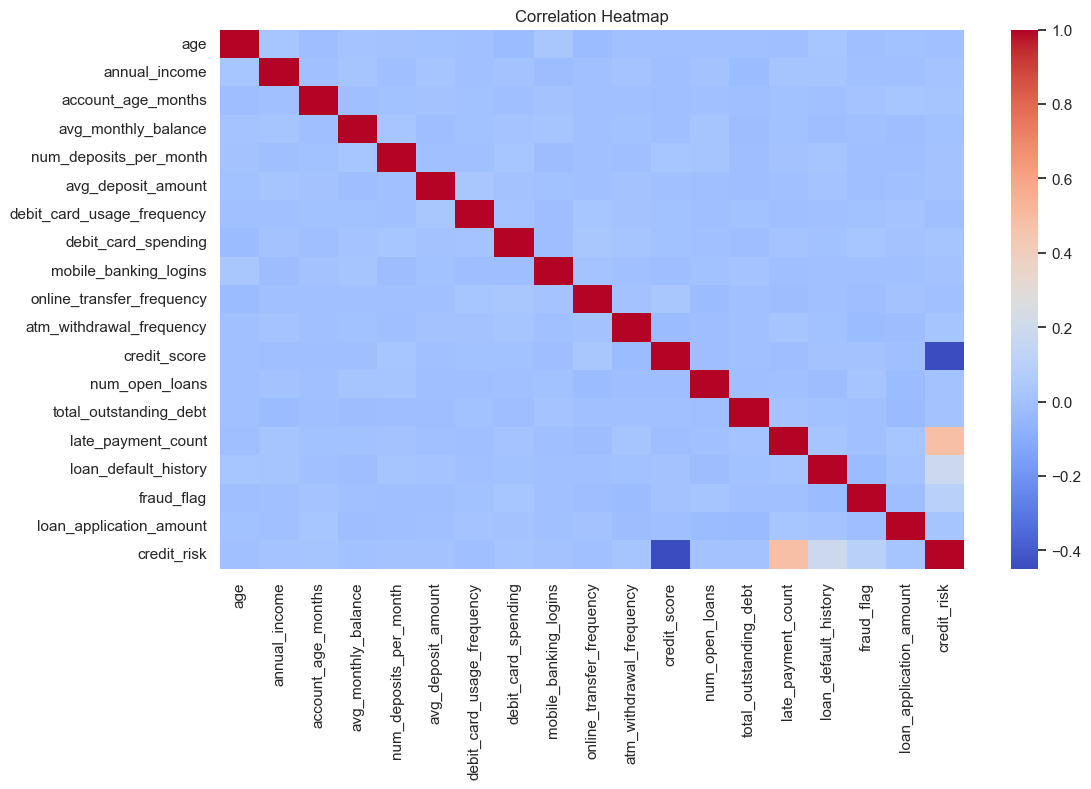

EDA Done 🚀


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\AS\Downloads\archive(5)\credit_risk_dataset.csv")

sns.set(style="whitegrid")

print("Shape:", df.shape)

# =========================
# 1. TARGET (credit_risk)
# =========================
plt.figure(figsize=(6,4))
df['credit_risk'].value_counts().plot(kind='bar')
plt.title("Credit Risk Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Count")
plt.show()

# =========================
# 2. AGE
# =========================
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# =========================
# 3. ANNUAL INCOME
# =========================
plt.figure(figsize=(6,4))
sns.histplot(df['annual_income'], bins=30, kde=True)
plt.title("Annual Income Distribution")
plt.show()

# =========================
# 4. CREDIT SCORE
# =========================
plt.figure(figsize=(6,4))
sns.histplot(df['credit_score'], bins=30, kde=True)
plt.title("Credit Score Distribution")
plt.show()

# =========================
# 5. DEBT vs INCOME (important insight)
# =========================
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='annual_income', y='total_outstanding_debt', hue='credit_risk')
plt.title("Income vs Debt (Risk Colored)")
plt.show()

# =========================
# 6. MONTHLY BALANCE
# =========================
plt.figure(figsize=(6,4))
sns.histplot(df['avg_monthly_balance'], bins=30, kde=True)
plt.title("Avg Monthly Balance")
plt.show()

# =========================
# 7. LATE PAYMENTS IMPACT
# =========================
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='credit_risk', y='late_payment_count')
plt.title("Late Payments vs Credit Risk")
plt.show()

# =========================
# 8. EMPLOYMENT STATUS vs RISK
# =========================
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='employment_status', hue='credit_risk')
plt.xticks(rotation=45)
plt.title("Employment vs Credit Risk")
plt.show()

# =========================
# 9. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(12,7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

print("EDA Done 🚀")

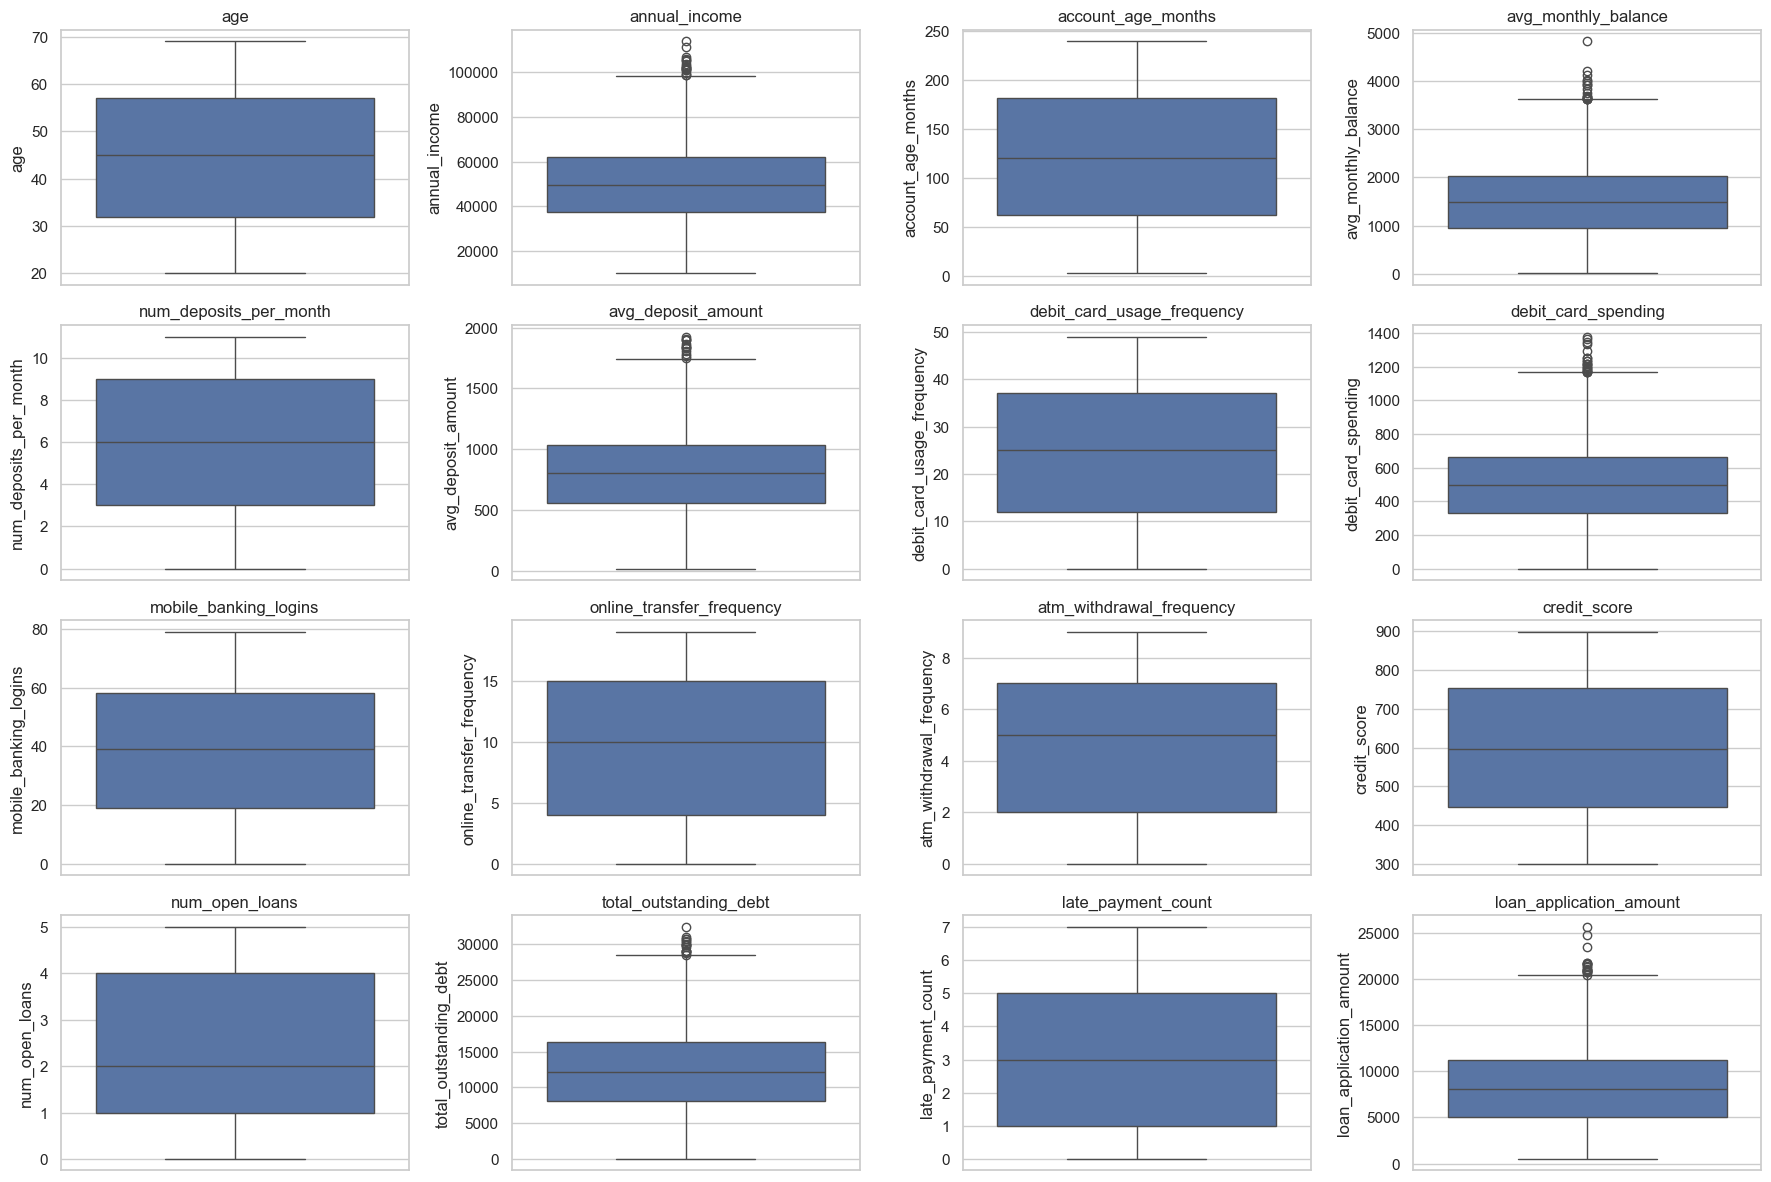

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\AS\Downloads\archive(5)\credit_risk_dataset.csv")

num_cols = [
    'age', 'annual_income', 'account_age_months', 'avg_monthly_balance',
    'num_deposits_per_month', 'avg_deposit_amount',
    'debit_card_usage_frequency', 'debit_card_spending',
    'mobile_banking_logins', 'online_transfer_frequency',
    'atm_withdrawal_frequency', 'credit_score',
    'num_open_loans', 'total_outstanding_debt',
    'late_payment_count', 'loan_application_amount'
]

plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

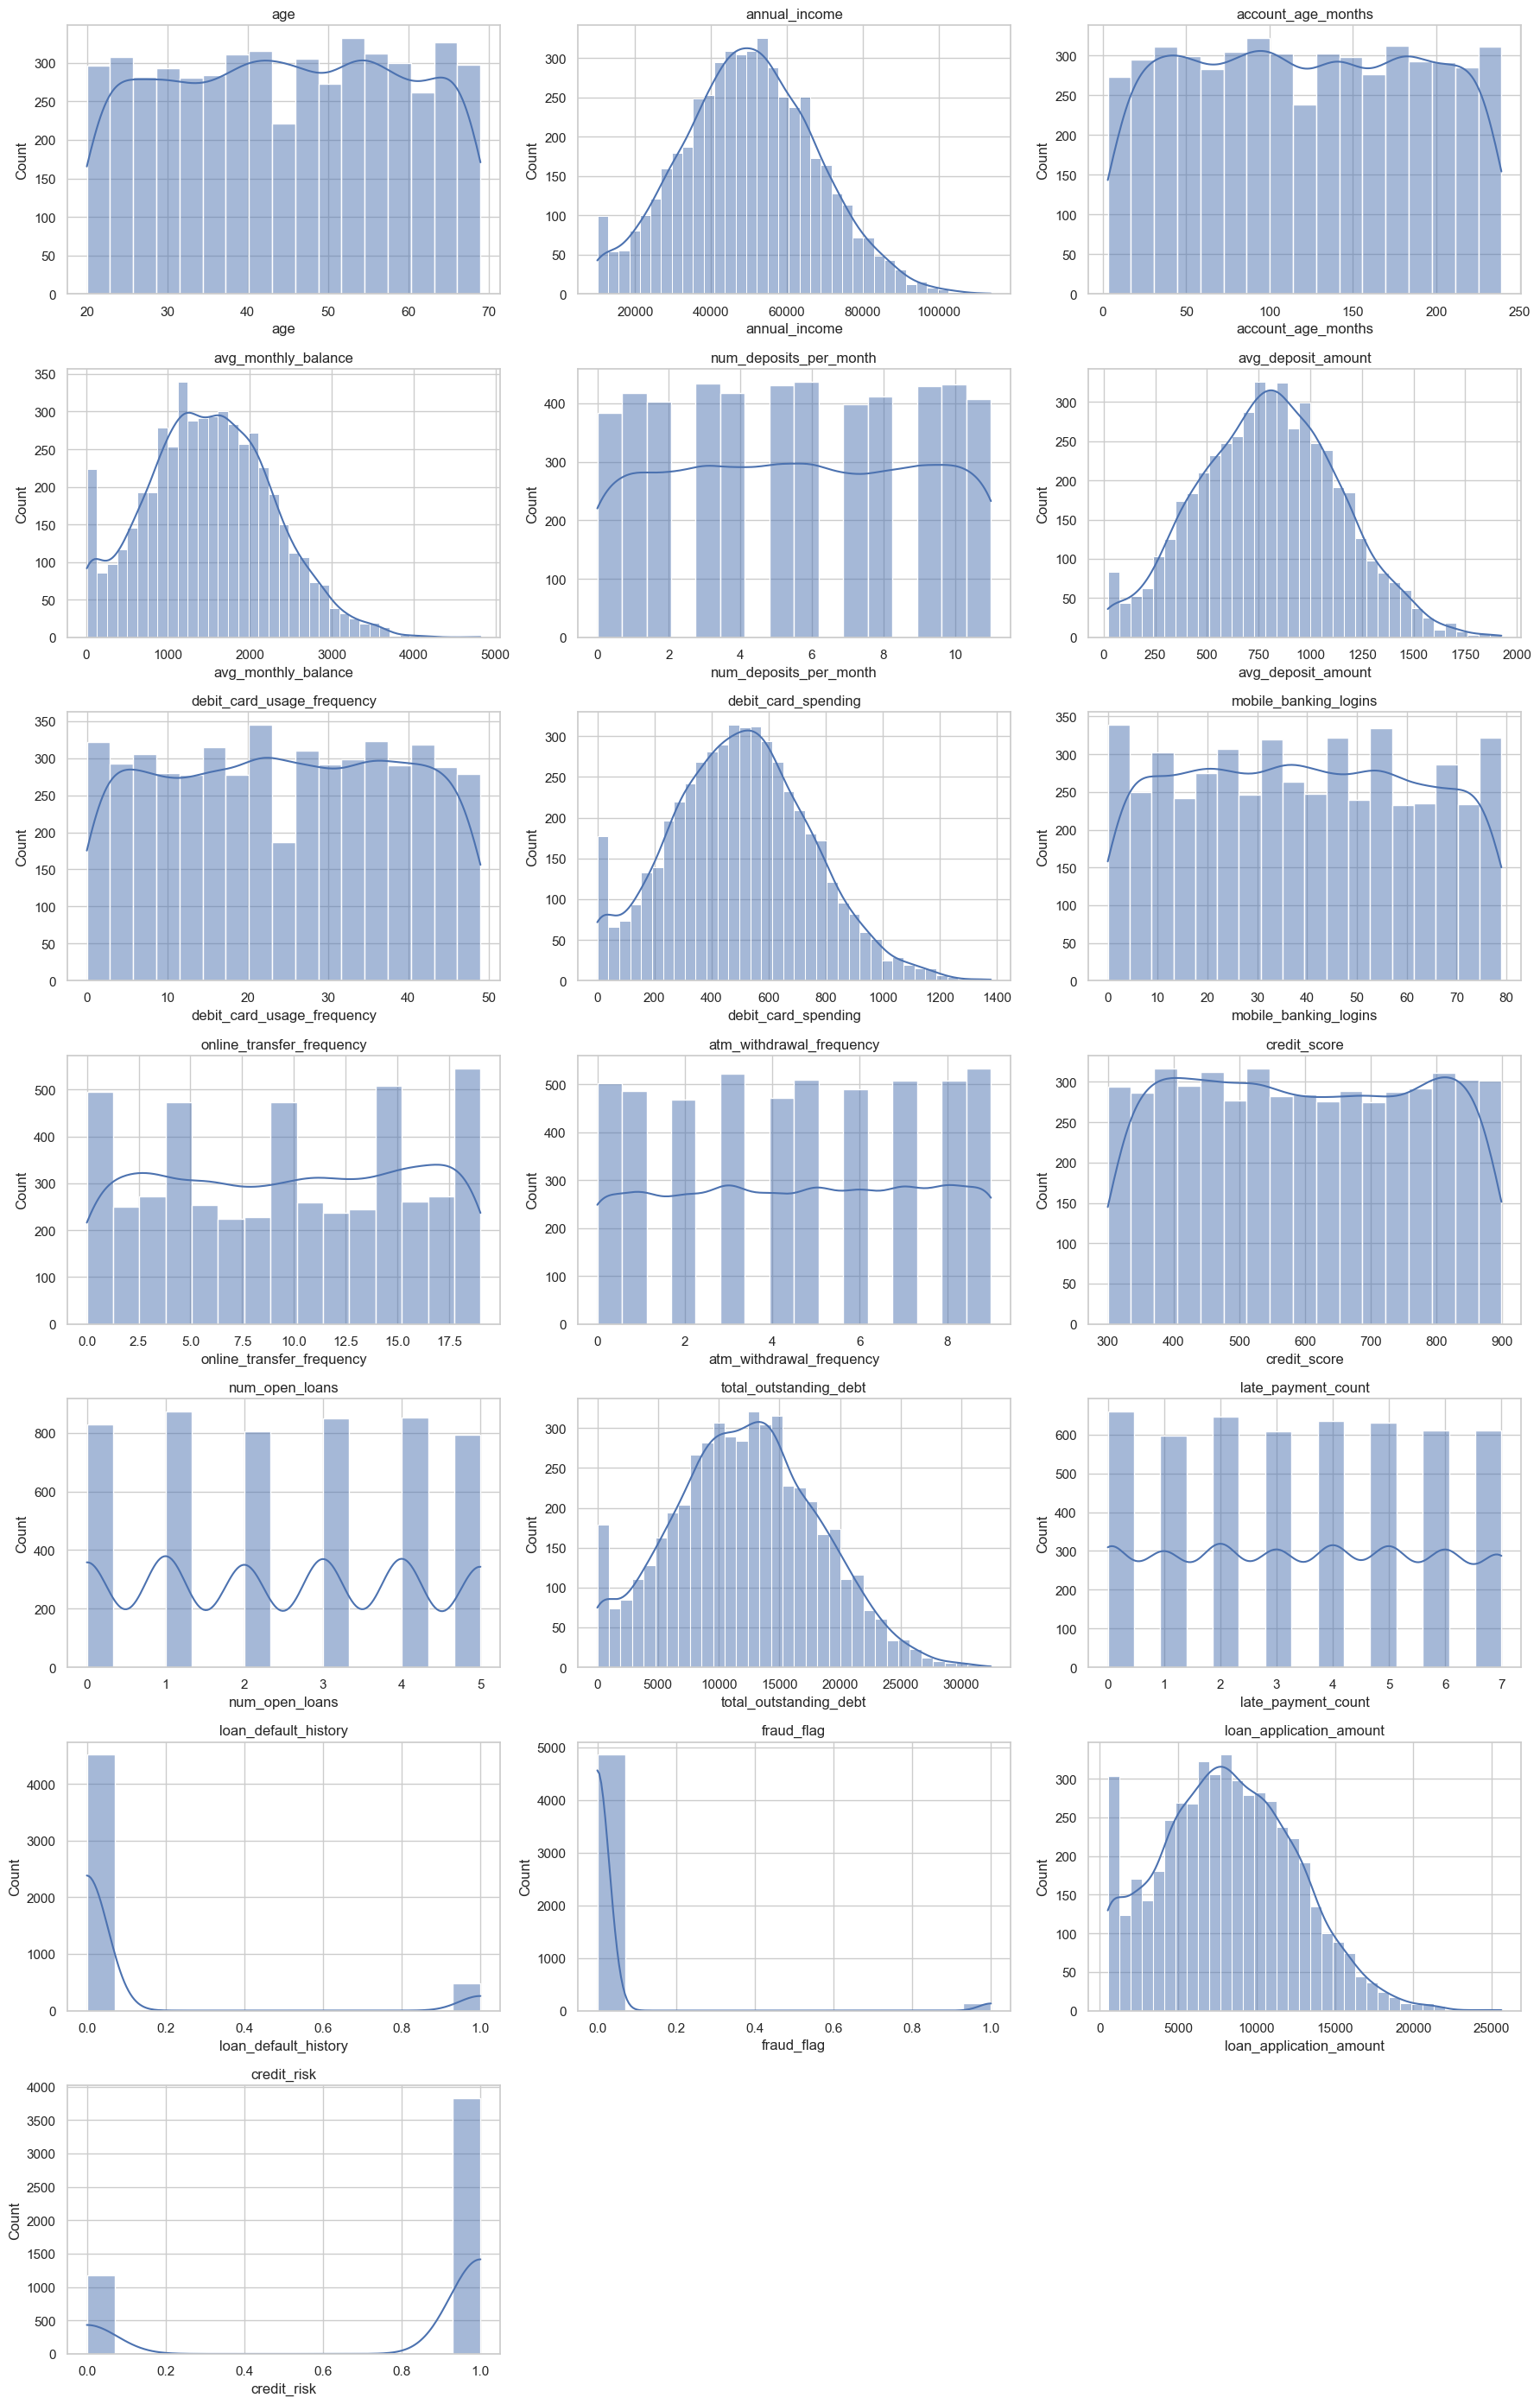

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = ['age', 'annual_income', 'account_age_months', 'avg_monthly_balance',
            'num_deposits_per_month', 'avg_deposit_amount',
            'debit_card_usage_frequency', 'debit_card_spending',
            'mobile_banking_logins', 'online_transfer_frequency',
            'atm_withdrawal_frequency', 'credit_score', 'num_open_loans',
            'total_outstanding_debt', 'late_payment_count',
            'loan_default_history', 'fraud_flag', 'loan_application_amount',
            'credit_risk']

n_cols = 3  # عدد الأعمدة في الشكل
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 4*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [1]:
df['credit_risk'].value_counts(normalize=True)
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
sns.boxplot(x='credit_risk', y='annual_income', data=df)

NameError: name 'df' is not defined